# 07  Adzuna hiring signals

Notebook 6 added public contract wins. Those lean towards larger firms. This notebook adds a
signal that reaches smaller firms: **hiring**. A company advertising jobs is usually growing or
busy, which is a useful commercial signal.

The data comes from Adzuna, a jobs website with a free data service. Each advert gives the
employer name, the town, a salary, a date, and a category, but no company number and no
postcode. So we can only confirm a name match using the town, which is coarser than the postcode
we used for contracts. Company level hiring matches are therefore a bit less certain, and we mark
them with a lower confidence.

To balance that, the notebook also builds an **aggregate hiring view by sector**. That does not
depend on matching a single company, so it covers every firm in our list through its sector, and
it is the more reliable part for small firms.

You need a free Adzuna key to run this. Register at developer.adzuna.com, which gives you an
app_id and an app_key. The notebook asks for them when you run it; they are not saved.


## 1. Install and import

In [1]:
import sys, subprocess
try:
    import duckdb
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "duckdb"], check=True)

In [2]:
import duckdb
import pandas as pd
import requests
import re, time
from collections import defaultdict
from datetime import datetime, timezone
print("duckdb", duckdb.__version__, "| pandas", pd.__version__)

duckdb 1.3.2 | pandas 2.2.2


## 2. Find the database, the key, and the options
Finds the database the spine notebook built, asks for your Adzuna key, and sets how much to pull.
PAGES times RESULTS_PER_PAGE is the rough number of adverts we download, so keep it modest to
stay inside the free limit.

In [3]:
from pathlib import Path
from getpass import getpass

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    DB_PATH = Path("/content/drive/MyDrive/Lloyds/lloyds.duckdb")
else:
    DB_PATH = Path("..").resolve() / "data" / "processed" / "lloyds.duckdb"
assert DB_PATH.exists(), f"lloyds.duckdb not found at {DB_PATH}. Run NB05 first."
print("DB:", DB_PATH)

ADZUNA_APP_ID  = getpass("Adzuna app_id: ").strip()
ADZUNA_APP_KEY = getpass("Adzuna app_key: ").strip()

PAGES            = 20     # number of search pages to pull
RESULTS_PER_PAGE = 50     # adverts per page (Adzuna max is 50)
USER_AGENT = "LloydsBCB-MSc-project/1.0 (academic; contact via GitHub elyokerr)"
NOW = datetime.now(timezone.utc).isoformat(timespec="seconds")

Mounted at /content/drive
DB: /content/drive/MyDrive/Lloyds/lloyds.duckdb
Adzuna app_id: ··········
Adzuna app_key: ··········


## 3. Helpers
The same name cleaner as the other notebooks, plus a town cleaner so town names compare fairly.

In [4]:
_SUFFIXES = ["LIMITED","LTD","PLC","PUBLIC LIMITED COMPANY","LLP",
             "LIMITED LIABILITY PARTNERSHIP","LP","CIC","CIO","COMPANY","CO","AND","THE"]
_SUFFIX_RE = re.compile(r"\b(" + "|".join(_SUFFIXES) + r")\b")

def normalise_name(name):
    if name is None:
        return None
    s = str(name).upper()
    s = re.sub(r"[^A-Z0-9 ]", " ", s)
    s = _SUFFIX_RE.sub(" ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s or None

def normalise_town(town):
    if town is None:
        return None
    s = re.sub(r"[^A-Z ]", " ", str(town).upper())
    s = s.replace("CITY OF", "").replace("GREATER", "")
    s = re.sub(r"\s+", " ", s).strip()
    return s or None

def location_tokens(loc):
    # Adzuna's area is a hierarchy like ["UK","Northern Ireland","Belfast","Ormeau"], so the town
    # can be in the middle, not the last item. Collect every level (and the display name parts)
    # into a set, so a company's registered town can be matched against any of them.
    if not loc:
        return ""
    area = loc.get("area") or []
    toks = set(t for t in (normalise_town(a) for a in area[1:]) if t)   # skip the top "UK"
    toks |= set(t for t in (normalise_town(x) for x in str(loc.get("display_name", "")).split(",")) if t)
    return "|".join(sorted(toks))

print("helpers ok")

helpers ok


## 4. Load the spine and build the name lookup
Reads the company list with its town, and builds an index from the simplified name to the
companies that have it, each with its town for confirming a match.

In [5]:
con = duckdb.connect(str(DB_PATH))
spine = con.execute("SELECT company_number, name_norm, post_town FROM companies").df()
print(f"spine: {len(spine):,} companies")

by_name = defaultdict(list)     # name_norm -> [(company_number, town), ...]
for cn, nm, tw in zip(spine["company_number"], spine["name_norm"], spine["post_town"]):
    if not nm:
        continue
    by_name[nm].append((cn, normalise_town(tw)))
print(f"exact-name keys: {len(by_name):,}")

spine: 869,043 companies
exact-name keys: 868,166


## 5. The matching ladder (town confirmed, exact name only)
Adzuna gives no company number and no postcode, only a town, which is coarse. A live test showed
that fuzzy name matching plus a town produces false positives: big employers like a stock exchange
group or a software firm get matched to small companies that share a first word and sit in the
same large city. So for Adzuna we keep only the safe tiers: an exact name where the town agrees
(0.8), and a weak exact name where no town was given to confirm with (0.5). If a town is given and
it does not match, we do not claim a match. This is deliberately strict, so coverage is small but
the matches are trustworthy. The broad small-firm picture comes from the sector view in step 8.

In [6]:
def match_employer(name, loc):
    nm = normalise_name(name)
    if not nm:
        return None, 0.0, "no_match"
    towns = set(loc.split("|")) if loc else set()

    if nm in by_name:
        cands = by_name[nm]                          # [(company_number, town), ...]
        confirmed = [c for c, ct in cands if ct and ct in towns]
        if confirmed:
            return confirmed[0], 0.8, "name_exact_town"
        if towns:
            return None, 0.0, "name_exact_town_mismatch"
        if len(cands) == 1:
            return cands[0][0], 0.5, "name_exact_unconfirmed"
        return None, 0.0, "name_exact_ambiguous"

    # no fuzzy tier for Adzuna: a town is too coarse to confirm a fuzzy name safely
    return None, 0.0, "no_match"

print(match_employer("AAR SERVICES LIMITED", ""))

('01203916', 0.5, 'name_exact_unconfirmed')


## 6. Pull job adverts from Adzuna
Downloads recent GB adverts page by page. For each advert we keep the employer, the town, the
salary, the date, and the category. Results are cached so re-running is instant. If the free
limit is hit (a 429 reply), it stops politely and keeps what it has.

In [7]:
ADZUNA_URL = "https://api.adzuna.com/v1/api/jobs/gb/search/{page}"

def fetch_jobs(pages=PAGES, per_page=RESULTS_PER_PAGE):
    cache = DB_PATH.parent / f"cache_adzuna_{pages}x{per_page}.parquet"
    if cache.exists():
        print("  using cached Adzuna pull")
        return pd.read_parquet(cache)
    rows = []
    for page in range(1, pages + 1):
        r = requests.get(
            ADZUNA_URL.format(page=page),
            params={"app_id": ADZUNA_APP_ID, "app_key": ADZUNA_APP_KEY,
                    "results_per_page": per_page, "content-type": "application/json",
                    "sort_by": "date"},
            headers={"User-Agent": USER_AGENT}, timeout=60,
        )
        if r.status_code == 429:
            print(f"  rate limited at page {page}, stopping (re-run later to continue)")
            break
        if r.status_code in (401, 403):
            raise RuntimeError("Adzuna rejected the key. Check app_id and app_key.")
        r.raise_for_status()
        results = r.json().get("results", [])
        if not results:
            break
        for j in results:
            rows.append({
                "employer": (j.get("company") or {}).get("display_name"),
                "loc": location_tokens(j.get("location")),
                "category": (j.get("category") or {}).get("label"),
                "salary_min": j.get("salary_min"),
                "created": j.get("created"),
                "title": j.get("title"),
            })
        time.sleep(0.3)
    df = pd.DataFrame(rows, columns=["employer","loc","category","salary_min","created","title"])
    df.to_parquet(cache, index=False)
    return df

jobs = fetch_jobs()
print(f"  adverts pulled: {len(jobs):,}")
print(f"  with an employer name: {jobs['employer'].notna().sum():,}")
print(f"  with a location:       {(jobs['loc'] != '').sum():,}")
jobs.head(3)

  adverts pulled: 1,000
  with an employer name: 1,000
  with a location:       1,000


,employer,loc,category,salary_min,created,title
0,SCP Recruitment Limited,CHATHAM|KENT|SOUTH EAST ENGLAND,Healthcare & Nursing Jobs,45313.76,2026-07-01T13:52:56Z,Support Worker
1,SCP Recruitment Limited,KENT|MAIDSTONE|SOUTH EAST ENGLAND,Healthcare & Nursing Jobs,45432.27,2026-07-01T13:52:56Z,Support Worker
2,London Care Limited,LONDON|UK,Social work Jobs,28717.13,2026-07-01T13:52:56Z,Care Assistant


## 7. Match employers to the spine and write hiring signals
Runs each advert's employer through the ladder, keeps the matches, and groups them by company so
each firm gets one hiring signal with the number of adverts as its value. Old Adzuna rows are
cleared first so re-running does not double count.

In [8]:
matches = []
for row in jobs.itertuples(index=False):
    cn, conf, method = match_employer(row.employer, row.loc)
    if cn:
        matches.append({"company_number": cn, "created": row.created, "title": row.title,
                        "confidence": conf, "method": method})

m = pd.DataFrame(matches, columns=["company_number","created","title","confidence","method"])
print(f"adverts matched to a company in the dataset: {len(m):,} of {len(jobs):,}")
if len(m):
    print("\nby method:")
    print(m["method"].value_counts().to_string())

# one hiring signal per company: value = number of adverts, date = most recent advert
if len(m):
    m["created_dt"] = pd.to_datetime(m["created"], errors="coerce", utc=True)
    agg = (m.groupby("company_number")
             .agg(value=("title", "size"),
                  signal_date=("created_dt", "max"),
                  confidence=("confidence", "max"),
                  detail=("title", "first"))
             .reset_index())
    agg["signal_date"] = agg["signal_date"].dt.date
    agg["detail"] = agg["value"].astype(str) + " job advert(s), e.g. " + agg["detail"].fillna("")
    agg["signal_type"] = "hiring"
    agg["source"] = "adzuna"
    agg["retrieved_at"] = NOW

    con.execute("DELETE FROM signals WHERE source = 'adzuna'")
    ins = agg[["company_number","signal_type","signal_date","value","detail",
               "source","confidence","retrieved_at"]]
    con.register("tmp_h", ins)
    con.execute("""INSERT INTO signals
                   SELECT company_number, signal_type, signal_date, value, detail,
                          source, confidence, retrieved_at FROM tmp_h""")
    con.unregister("tmp_h")
    print(f"\ncompanies given a hiring signal: {len(ins):,}")
else:
    print("no company-level matches this run")

adverts matched to a company in the dataset: 1 of 1,000

by method:
method
name_exact_town    1

companies given a hiring signal: 1


## 8. Aggregate hiring demand (covers the whole picture)
Matching single firms is thin because the job feed is mostly large employers. To give a picture
that covers everyone, we ask Adzuna how many jobs are advertised right now in each industry and
in each region. We only read the total count, not the adverts, so this is a few dozen light calls.
This is the hiring demand backdrop: which industries and which areas are busy, which is context for
every company in our list through its sector and its area.

In [9]:
ADZUNA_BASE = "https://api.adzuna.com/v1/api/jobs/gb"
_P = {"app_id": ADZUNA_APP_ID, "app_key": ADZUNA_APP_KEY, "content-type": "application/json"}

def adzuna_count(extra):
    r = requests.get(f"{ADZUNA_BASE}/search/1",
                     params={**_P, "results_per_page": 1, **extra},
                     headers={"User-Agent": USER_AGENT}, timeout=60)
    r.raise_for_status()
    return r.json().get("count", 0)

# hiring demand by industry category
cats = requests.get(f"{ADZUNA_BASE}/categories", params=_P,
                    headers={"User-Agent": USER_AGENT}, timeout=60).json().get("results", [])
rows = []
for c in cats:
    if c.get("tag") == "unknown":
        continue
    rows.append({"industry": c.get("label"), "adverts": adzuna_count({"category": c.get("tag")})})
    time.sleep(0.2)
cat_demand = pd.DataFrame(rows).sort_values("adverts", ascending=False).reset_index(drop=True)
print("Hiring demand by industry (current open adverts):")
print(cat_demand.head(12).to_string(index=False))

Hiring demand by industry (current open adverts):
                     industry  adverts
                Teaching Jobs   196423
    Trade & Construction Jobs    66782
             Engineering Jobs    62396
Domestic help & Cleaning Jobs    58238
                      IT Jobs    46987
               Part time Jobs    43534
  Hospitality & Catering Jobs    40457
                   Sales Jobs    39204
    Accounting & Finance Jobs    32987
   Logistics & Warehouse Jobs    32315
    Healthcare & Nursing Jobs    29462
             Social work Jobs    25781


In [10]:
# hiring demand by region: major UK cities and nations (these geocode reliably via where=)
REGIONS = ["London","Birmingham","Manchester","Leeds","Glasgow","Liverpool","Bristol",
           "Sheffield","Edinburgh","Cardiff","Belfast","Newcastle upon Tyne","Nottingham",
           "Leicester","Scotland","Wales"]
reg_demand = pd.DataFrame({"area": REGIONS,
                           "adverts": [adzuna_count({"where": rg}) for rg in REGIONS]})
reg_demand = reg_demand.sort_values("adverts", ascending=False).reset_index(drop=True)
print("Hiring demand by area (current open adverts):")
print(reg_demand.to_string(index=False))

Hiring demand by area (current open adverts):
               area  adverts
             London   142614
           Scotland    34842
              Wales    18696
         Manchester    17620
         Birmingham    15604
            Bristol    12941
              Leeds     9399
         Nottingham     7201
          Liverpool     7076
            Glasgow     5974
          Leicester     5357
Newcastle upon Tyne     4733
          Sheffield     4672
          Edinburgh     4178
            Belfast     4038
            Cardiff     2931


## 9. Charts
Top row is the per-company matching (the funnel, and how the few matches were made). Bottom row is
the full-coverage hiring demand: the busiest industries and the busiest areas.

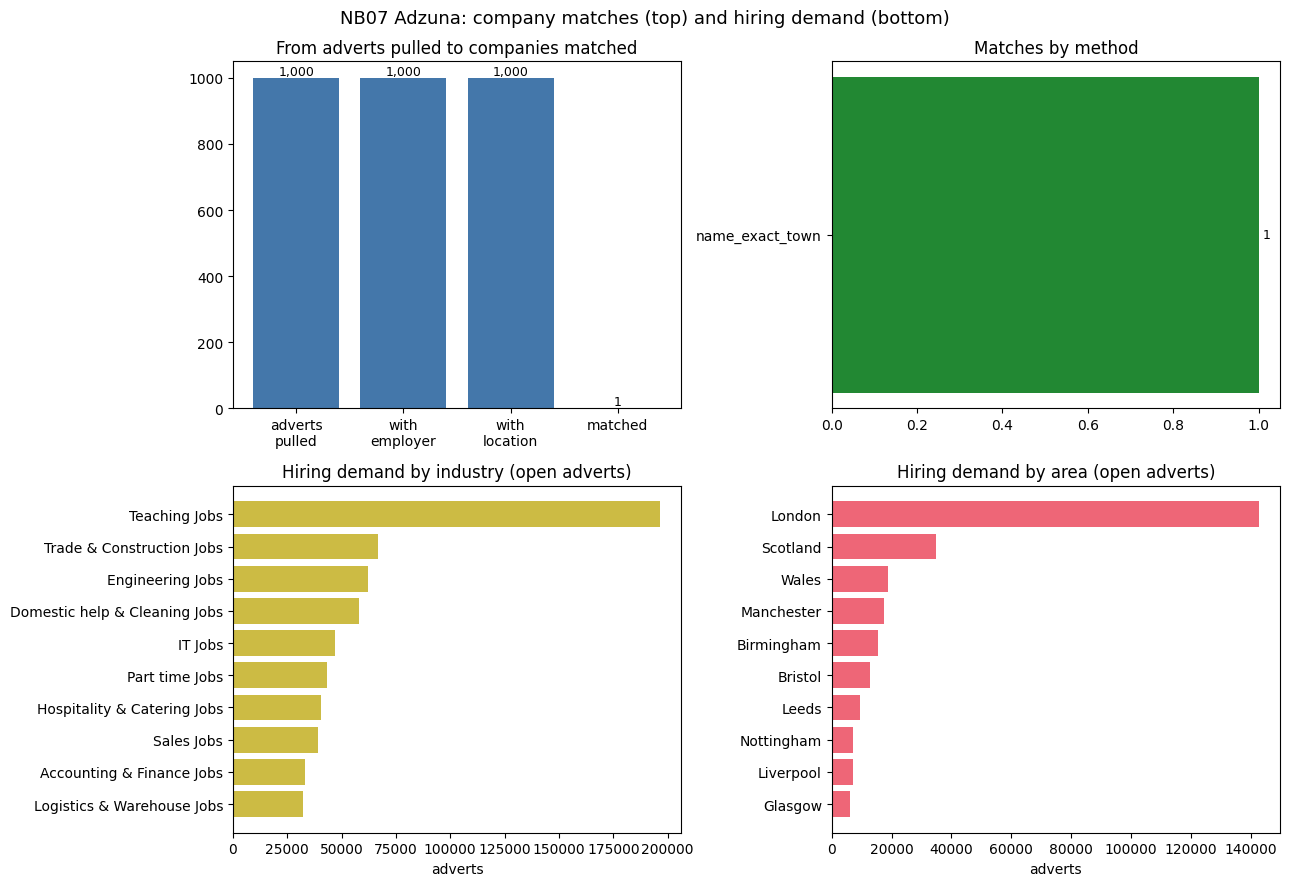

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(13, 9))

# A. per-company funnel
funnel = {"adverts\npulled": len(jobs),
          "with\nemployer": int(jobs["employer"].notna().sum()),
          "with\nlocation": int((jobs["loc"] != "").sum()),
          "matched": len(m)}
ax[0, 0].bar(list(funnel), list(funnel.values()), color="#4477aa")
ax[0, 0].set_title("From adverts pulled to companies matched")
for i, v in enumerate(funnel.values()):
    ax[0, 0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

# B. matches by method
if len(m):
    mm = m["method"].value_counts()
    ax[0, 1].barh(list(mm.index[::-1]), list(mm.values[::-1]), color="#228833")
    for i, v in enumerate(mm.values[::-1]):
        ax[0, 1].text(v, i, f" {v}", va="center", fontsize=9)
    ax[0, 1].set_title("Matches by method")
else:
    ax[0, 1].set_visible(False)

# C. hiring demand by industry (top 10)
c10 = cat_demand.head(10)
ax[1, 0].barh(c10["industry"][::-1], c10["adverts"][::-1], color="#ccbb44")
ax[1, 0].set_title("Hiring demand by industry (open adverts)")
ax[1, 0].set_xlabel("adverts")

# D. hiring demand by area (top 10)
r10 = reg_demand.head(10)
ax[1, 1].barh(r10["area"][::-1], r10["adverts"][::-1], color="#ee6677")
ax[1, 1].set_title("Hiring demand by area (open adverts)")
ax[1, 1].set_xlabel("adverts")

fig.suptitle("NB07 Adzuna: company matches (top) and hiring demand (bottom)", fontsize=13)
fig.tight_layout()
plt.show()

## 10. Save and close

In [12]:
con.close()
print("saved:", DB_PATH)

saved: /content/drive/MyDrive/Lloyds/lloyds.duckdb


## Notes
- Two outputs here, on purpose. The per-company matches are accurate but few: the public job feed
  is mostly large employers, so only a handful of our small firms appear by exact name. Those that
  do are confirmed by town and written into the signals table.
- The hiring demand by industry and by area covers everyone: it is the backdrop a company sits in,
  joinable through its sector and its area, and it is the more useful Adzuna output for small firms.
- The signals table now holds contract wins and hiring on one spine. The same pattern takes the
  team's news features next.
- To grow the per-company matches, raise PAGES (mind the free limit). It will not change much,
  because the feed composition is the real limit, not the page count.